In [ ]:
# ============================================
# 1) Setup
# ============================================

!pip -q install kagglehub

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup listo.")

Setup listo.


In [ ]:
# ============================================
# 2) Descargar y cargar dataset
# ============================================

import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Carpeta descargada:", path)

# Truquito: buscamos el CSV dentro de la carpeta
csv_path = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

print(" SV encontrado:", csv_path)

df = pd.read_csv(csv_path)
print("Data cargada. Tamaño:", df.shape)
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Carpeta descargada: /kaggle/input/telco-customer-churn
 SV encontrado: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Data cargada. Tamaño: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ============================================
# 3) Limpieza mínima y preparación de target
# ============================================

df = df.copy()
df.columns = [c.strip() for c in df.columns]  # por si hay espacios raros

# 1) customerID no sirve para predecir churn (es un identificador), entonces chao.
if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True)

# 2) TotalCharges viene como string y trae algunos " " (espacios vacíos).
#    Los convertimos a NaN y luego a numérico.
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"].astype(str).str.strip().replace({"": np.nan}),
        errors="coerce"
    )

# 3) Target: Churn Yes/No -> 1/0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Separar variables y target
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

print(" X shape:", X.shape, "| y shape:", y.shape)
print("Distribución de clases (0=No churn, 1=Churn):")
print(y.value_counts(), "\n")
print(" Proporciones:")
print(y.value_counts(normalize=True))

 X shape: (7043, 19) | y shape: (7043,)
Distribución de clases (0=No churn, 1=Churn):
Churn
0    5174
1    1869
Name: count, dtype: int64 

 Proporciones:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## Modelos seleccionados

Con base en la crítica de hipótesis, se seleccionaron:

• Random Forest: por su robustez y capacidad de generalización.  
• SVM: por su enfoque de margen máximo y buen desempeño en espacios de alta dimensionalidad.

In [ ]:
# ============================================
# 4) Preprocesamiento: imputación + OneHotEncoder
# ============================================

# Detectar columnas numéricas/categóricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print(" Numéricas:", numeric_features)
print(" Categóricas:", categorical_features)

# Para numéricas: imputar mediana (por si TotalCharges tiene NaN)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Para categóricas: imputar moda + OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Juntar todo en un solo preprocesador
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocesador listo.")

 Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
 Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocesador listo.


In [ ]:
# ============================================
# 5) Validación y métricas (lo importante: Recall/F1 para Churn)
# ============================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ojo: en sklearn 'recall' y 'f1' se calculan para la clase positiva (=1), perfecto para churn.
scoring = {
    "accuracy": "accuracy",
    "precision_churn": "precision",
    "recall_churn": "recall",
    "f1_churn": "f1",
    "roc_auc": "roc_auc"
}

print(" CV y métricas configuradas.")

In [ ]:
# ============================================
# 6) Modelo 1: Random Forest (con class_weight balanced)
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=400,          # muchos arbolitos = mejor estabilidad
    max_features="sqrt",
    class_weight="balanced",   # por el desbalance (churn es minoría)
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf_model)
])

print(" Corriendo validación cruzada para Random Forest...")
rf_cv = cross_validate(
    rf_pipeline, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

rf_results = pd.DataFrame(rf_cv)
rf_summary = rf_results.filter(like="test_").agg(["mean", "std"]).T
rf_summary.columns = ["mean", "std"]

print(" Resultados RF (promedio y desviación):")
rf_summary

 Corriendo validación cruzada para Random Forest...
 Resultados RF (promedio y desviación):


,mean,std
test_accuracy,0.787020,0.009513
test_precision_churn,0.630307,0.018389
test_recall_churn,0.475633,0.036934
test_f1_churn,0.541866,0.030249
test_roc_auc,0.821835,0.014672


In [ ]:
# ============================================
# 7) Modelo 2: SVM (requiere escalado)
# ============================================
# SVM es delicado con escalas, así que ponemos StandardScaler.
# with_mean=False porque OHE produce matriz dispersa (sparse) y si centramos se vuelve densa.

svm_model = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,   # para poder sacar ROC-AUC con predict_proba
    random_state=RANDOM_STATE
)

svm_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", svm_model)
])

print("Corriendo validación cruzada para SVM...")
svm_cv = cross_validate(
    svm_pipeline, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

svm_results = pd.DataFrame(svm_cv)
svm_summary = svm_results.filter(like="test_").agg(["mean", "std"]).T
svm_summary.columns = ["mean", "std"]

print(" Resultados SVM (promedio y desviación):")
svm_summary

Corriendo validación cruzada para SVM...
 Resultados SVM (promedio y desviación):


,mean,std
test_accuracy,0.747974,0.009878
test_precision_churn,0.516826,0.012734
test_recall_churn,0.772053,0.021926
test_f1_churn,0.619144,0.015579
test_roc_auc,0.821752,0.013071


In [ ]:
# ============================================
# 8) Comparación RF vs SVM
# ============================================

compare = pd.DataFrame({
    "RF_mean": rf_summary["mean"],
    "RF_std": rf_summary["std"],
    "SVM_mean": svm_summary["mean"],
    "SVM_std": svm_summary["std"]
})

# Orden recomendado (lo que más importa en churn suele ser recall y f1 para la clase churn)
compare = compare.loc[
    ["test_f1_churn", "test_recall_churn", "test_precision_churn", "test_accuracy", "test_roc_auc"]
]

print(" Comparación final:")
compare

 Comparación final:


,RF_mean,RF_std,SVM_mean,SVM_std
test_f1_churn,0.541866,0.030249,0.619144,0.015579
test_recall_churn,0.475633,0.036934,0.772053,0.021926
test_precision_churn,0.630307,0.018389,0.516826,0.012734
test_accuracy,0.787020,0.009513,0.747974,0.009878
test_roc_auc,0.821835,0.014672,0.821752,0.013071


En general, la validación cruzada muestra que ambos modelos funcionan razonablemente bien, ya que los dos alcanzan un AUC cercano a 0.82, lo que indica que tienen una buena capacidad para diferenciar entre clientes que se van y clientes que se quedan. Es decir, los dos modelos “entienden” el problema.

Sin embargo, cuando miramos las métricas más importantes para el negocio (especialmente el recall para la clase Churn), aparecen diferencias claras. El modelo SVM logra un recall de aproximadamente 0.77, lo que significa que identifica cerca del 77% de los clientes que efectivamente se van. Esto es positivo, porque en un contexto real es más costoso no detectar a un cliente que está por irse que contactar por error a uno que no se iba a ir.

Por otro lado, Random Forest tiene mejor precisión, pero su recall es bastante más bajo (alrededor de 0.48), lo que implica que deja pasar muchos clientes que sí se van. En términos de negocio, esto puede ser problemático si el objetivo principal es reducir la fuga.

Comparando con lo planteado en la crítica de hipótesis, se puede decir que los umbrales esperados eran un poco optimistas, especialmente para Random Forest. SVM sí cumple con el recall propuesto (≥ 0.75), pero ninguno de los dos alcanza el F1-score ambicioso que se había planteado inicialmente.

En resumen, ambos modelos son válidos, pero si el objetivo es priorizar la detección de clientes en riesgo de fuga, el SVM se alinea mejor con esa meta, aunque a costa de generar más falsos positivos.

=== Random Forest (entrenado con todo) ===
[[5160   14]
 [   4 1865]]
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00      5174
       Churn       0.99      1.00      1.00      1869

    accuracy                           1.00      7043
   macro avg       1.00      1.00      1.00      7043
weighted avg       1.00      1.00      1.00      7043


=== SVM (entrenado con todo) ===
[[3936 1238]
 [ 310 1559]]
              precision    recall  f1-score   support

    No Churn       0.93      0.76      0.84      5174
       Churn       0.56      0.83      0.67      1869

    accuracy                           0.78      7043
   macro avg       0.74      0.80      0.75      7043
weighted avg       0.83      0.78      0.79      7043



<Figure size 640x480 with 0 Axes>

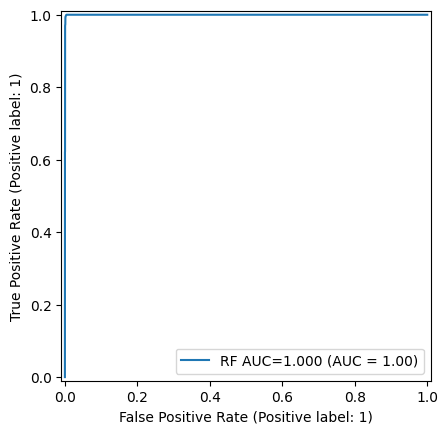

<Figure size 640x480 with 0 Axes>

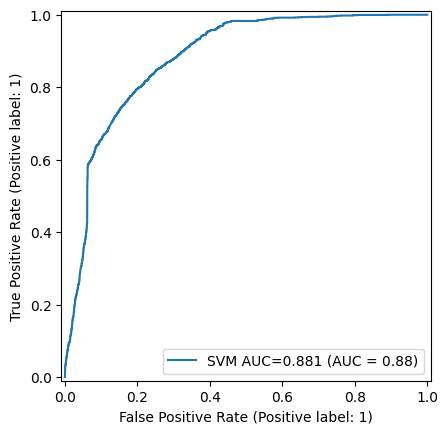

In [ ]:
# ============================================
# 9) Entrenamiento final (opcional) + reportes
# ============================================
# Esto no es CV; es entrenar con TODO el dataset para sacar reporte visual.
# Útil para el informe, pero la evaluación "que sí es" es la de validación cruzada.

rf_pipeline.fit(X, y)
svm_pipeline.fit(X, y)

rf_pred = rf_pipeline.predict(X)
svm_pred = svm_pipeline.predict(X)

print("=== Random Forest (entrenado con todo) ===")
print(confusion_matrix(y, rf_pred))
print(classification_report(y, rf_pred, target_names=["No Churn", "Churn"]))

print("\n=== SVM (entrenado con todo) ===")
print(confusion_matrix(y, svm_pred))
print(classification_report(y, svm_pred, target_names=["No Churn", "Churn"]))

# ROC curves (solo para ver algo bonito)
rf_proba = rf_pipeline.predict_proba(X)[:, 1]
svm_proba = svm_pipeline.predict_proba(X)[:, 1]

rf_auc = roc_auc_score(y, rf_proba)
svm_auc = roc_auc_score(y, svm_proba)

plt.figure()
RocCurveDisplay.from_predictions(y, rf_proba, name=f"RF AUC={rf_auc:.3f}")
plt.show()

plt.figure()
RocCurveDisplay.from_predictions(y, svm_proba, name=f"SVM AUC={svm_auc:.3f}")
plt.show()

Cuando el Random Forest se entrena y se evalúa usando todo el dataset, las métricas salen prácticamente perfectas (accuracy y AUC casi en 1). Pero eso no significa que el modelo sea “perfecto” en la vida real. Lo que realmente está pasando es que lo estamos evaluando con los mismos datos con los que aprendió, entonces básicamente los está recordando. Esto muestra que el modelo tiene una gran capacidad de memorización y probablemente está sobreajustando. De hecho, cuando lo comparamos con los resultados de validación cruzada, el recall baja bastante, lo que confirma que no generaliza tan bien como parecía al principio.

En cambio, el SVM muestra un comportamiento más consistente. Sus métricas cuando se entrena con todo el dataset no son perfectas, lo cual en realidad es buena señal, porque indica que no está simplemente memorizando los datos, sino aprendiendo una frontera de decisión más estable. Además, mantiene un buen recall para la clase Churn, que es justamente lo que más nos interesa desde el punto de vista del negocio.

En resumen, evaluar el modelo con todo el dataset sirve solo como referencia, pero no es una medida real del desempeño. La validación cruzada es la que realmente nos da una idea más confiable de cómo se comportaría el modelo con datos nuevos.

In [ ]:
# ============================================
# 10) CV OPTIMIZADA - RANDOM FOREST
# ============================================

from sklearn.model_selection import GridSearchCV

print(" Iniciando optimización de Random Forest...")

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", 0.5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",   # optimizamos F1 para la clase Churn (positiva)
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X, y)

print(" Mejores parámetros RF:")
print(rf_grid.best_params_)

print("Mejor F1 CV (RF):", rf_grid.best_score_)

 Iniciando optimización de Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
 Mejores parámetros RF:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
Mejor F1 CV (RF): 0.6291872087799449


In [ ]:
# ============================================
# 11) CV OPTIMIZADA - SVM
# ============================================

print(" Iniciando optimización de SVM...")

svm_param_grid = {
    "model__C": [0.5, 1, 2, 5],
    "model__gamma": ["scale", 0.1, 0.01],
    "model__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X, y)

print(" Mejores parámetros SVM:")
print(svm_grid.best_params_)

print(" Mejor F1 CV (SVM):", svm_grid.best_score_)

 Iniciando optimización de SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
 Mejores parámetros SVM:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
 Mejor F1 CV (SVM): 0.6202457308508629


In [ ]:
# ============================================
# 12) Comparación Optimizada
# ============================================

rf_best_f1 = rf_grid.best_score_
svm_best_f1 = svm_grid.best_score_

print("📊 F1 original RF:", rf_summary.loc["test_f1_churn", "mean"])
print("📊 F1 optimizado RF:", rf_best_f1)

print("📊 F1 original SVM:", svm_summary.loc["test_f1_churn", "mean"])
print("📊 F1 optimizado SVM:", svm_best_f1)

📊 F1 original RF: 0.5418664233335104
📊 F1 optimizado RF: 0.6291872087799449
📊 F1 original SVM: 0.6191439929659108
📊 F1 optimizado SVM: 0.6202457308508629


Después de hacer la optimización con GridSearchCV, se notó que el Random Forest sí mejoró bastante: su F1 pasó de 0.54 a 0.63. Eso básicamente nos dice que la configuración inicial no era la mejor y que ajustar los hiperparámetros sí ayudó a que el modelo generalizara mejor y no se quedara solo en una versión “rápida” del entrenamiento.

En cambio, en el SVM casi no hubo cambio. El F1 prácticamente se mantuvo igual, lo que sugiere que desde el inicio ya estaba funcionando cerca de su mejor punto posible con este dataset. Esto también puede indicar que el límite del rendimiento no depende tanto de ajustar parámetros, sino de la información que realmente contienen los datos.

En general, estos resultados muestran que el objetivo inicial de alcanzar un F1 ≥ 0.80 era bastante ambicioso para este problema. Más que verlo como un error, es parte del proceso: al probar y validar con datos reales, se entiende mejor hasta dónde pueden llegar los modelos con la información disponible.